In [2]:
using LinearAlgebra, Polynomials, Plots
using Revise, DelimitedFiles, BenchmarkTools
using CloudAtlas, BifurcationKit, ChannelflowWrapper

"""
    myreaddlm(filename, cc='%')

Read matrix or vector from a file, dropping comments marked with cc.
"""
function myreaddlm(filename; cc='%')
    X = readdlm(filename, comments=true, comment_char=cc)
    if size(X,2) == 1
        X = X[:,1]
    end
    X
end

macro suppress(ex)
    quote
        # Generate a unique name for the old stdout to avoid variable collision
        local old_stdout = stdout
        redirect_stdout(devnull)
        try
            # We use esc(ex) to run the expression in the caller's scope
            $(esc(ex))
        finally
            redirect_stdout(old_stdout)
        end
    end
end

sx, sy, sz, tx, tz = halfbox_symmetries()

pwd()

"/home/ebenq/Dev/julia/CloudAtlas.jl/notebooks/tw_bifurcations"

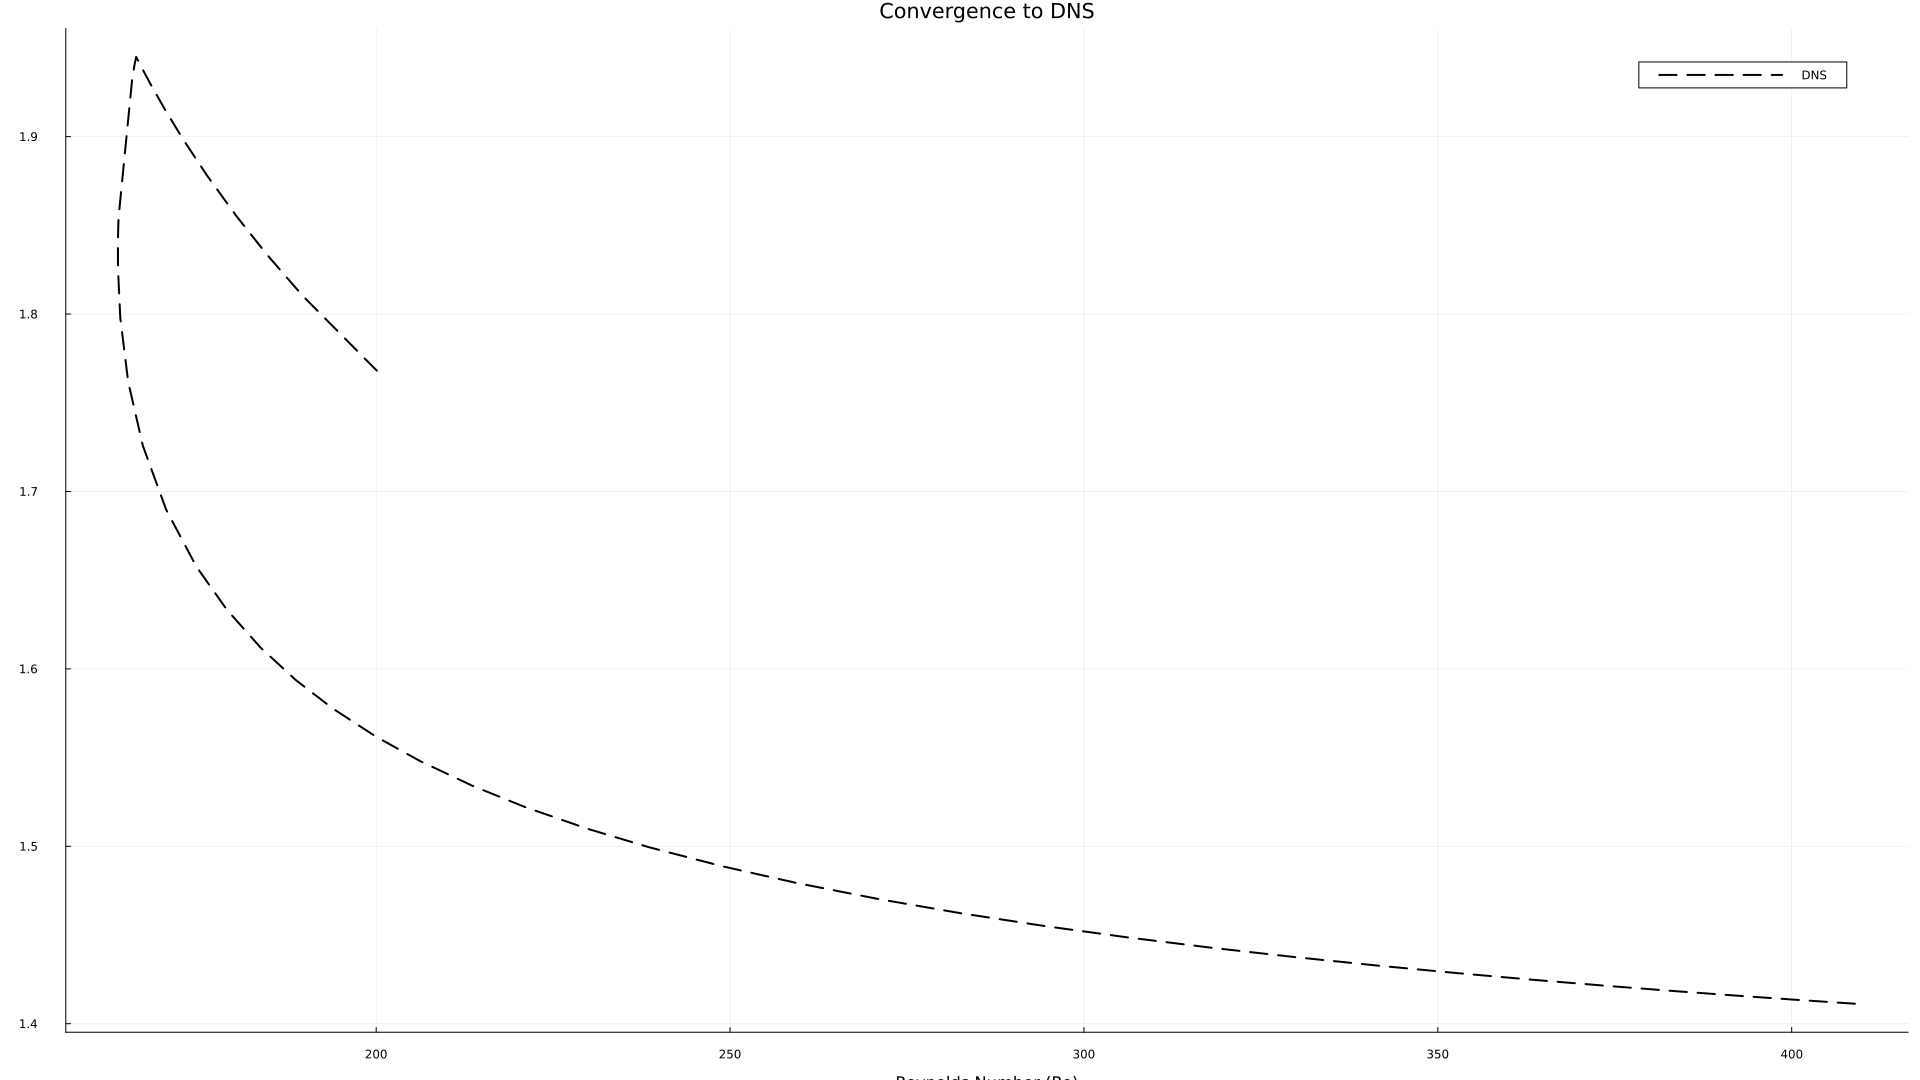

In [3]:
using Plots
# --- Plotting ---
p = plot(
    xlabel = "Reynolds Number (Re)",
    ylabel = "Power Input",
    title = "Convergence to DNS",
    legend = :topright,
    grid = true,
    size=(1920, 1080)
)

# Plot DNS Data
if isfile("tw1Re-DNS.asc")
    dns_data = myreaddlm("tw1Re-DNS.asc")
    plot!(p, dns_data[:,1], dns_data[:,2], 
        label="DNS", color=:black, linewidth=2, linestyle=:dash)
end

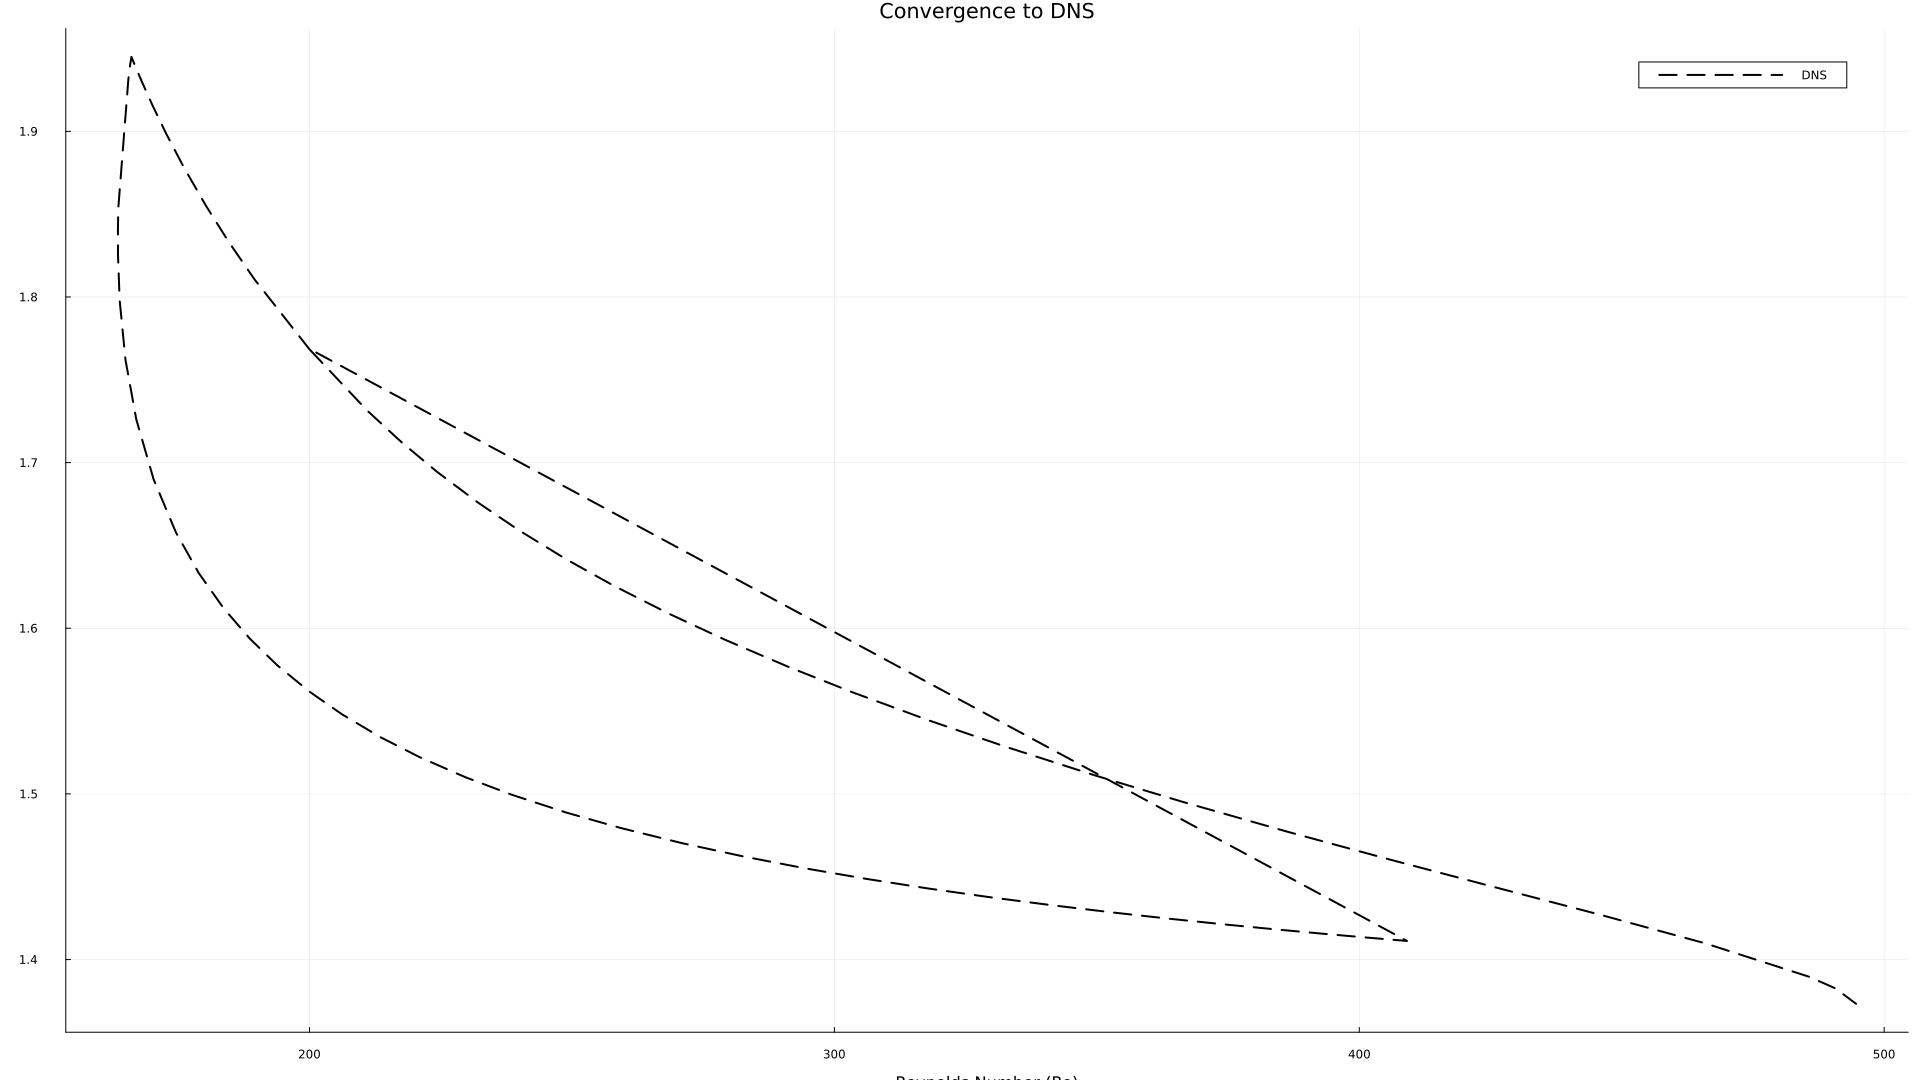

In [22]:
# --- Plotting ---
p = plot(
    xlabel = "Reynolds Number (Re)",
    ylabel = "Power Input",
    title = "Convergence to DNS",
    legend = :topright,
    grid = true,
    size=(1920, 1080)
)

# Plot DNS Data
if isfile("full_tw1Re-DNS.asc")
    dns_data = myreaddlm("full_tw1Re-DNS.asc")
    x = dns_data[:, 1]
    y = dns_data[:, 2]
    # 1. Find the order of indices that would sort x
    perm = sortperm(y)
    
    # 2. Reorder both x and y using that permutation
    x_sorted = x
    y_sorted = y
    
    # 3. Plot the sorted versions
    # plot(x_sorted, y_sorted)
    plot!(p, x_sorted, y_sorted,
        label="DNS", color=:black, linewidth=2, linestyle=:dash)
end

display(p)

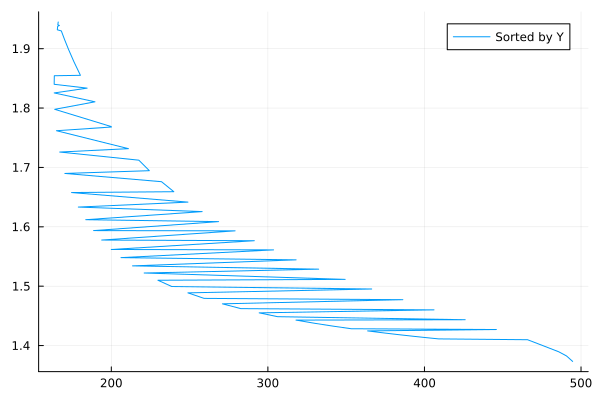

In [20]:
using LinearAlgebra
using CSV, DataFrames, Plots

# Load data
df = CSV.read("full_tw1Re-DNS.asc", DataFrame; delim=' ', ignorerepeated=true)

# Sort by the Y-axis ('obs') instead of X
sort!(df, :obs)

# Plot
plot(df[!, "%Re"], df[!, :obs], label="Sorted by Y")

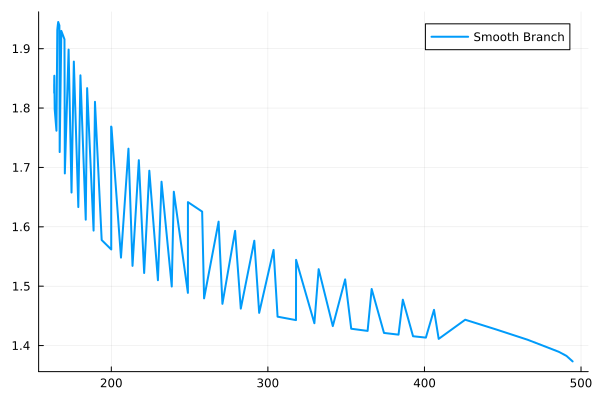

In [21]:
function sort_curve(x, y)
    n = length(x)
    # Create a list of indices we haven't visited yet
    remaining = collect(1:n)
    
    # Start at the point with the largest X value (usually the start of a branch)
    # You can change this to `argmin(x)` if your curve starts on the left
    current_idx = remaining[argmax(x)]
    
    sorted_indices = [current_idx]
    filter!(i -> i != current_idx, remaining)
    
    while !isempty(remaining)
        # Get coordinates of the current point
        curr_pt = [x[current_idx], y[current_idx]]
        
        # Find the nearest neighbor in the remaining list
        # We normalize x and y to ensure one axis doesn't dominate distance
        # (Optional: remove divisions if x and y scales are similar)
        dists = [norm([x[r], y[r]] - curr_pt) for r in remaining]
        
        nearest_loc = argmin(dists)
        next_idx = remaining[nearest_loc]
        
        # Add to sorted list and remove from remaining
        push!(sorted_indices, next_idx)
        current_idx = next_idx
        deleteat!(remaining, nearest_loc)
    end
    
    return sorted_indices
end

# --- usage ---

# Get the sorting order
p = sort_curve(df[!, "%Re"], df[!, :obs])

# Apply the order
df_sorted = df[p, :]

# Plot smooth curve
plot(df_sorted[!, "%Re"], df_sorted[!, :obs], lw=2, label="Smooth Branch")

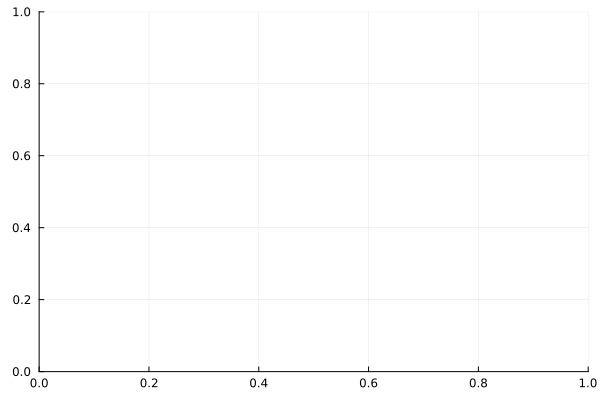

In [12]:
# --- Plotting ---
p = plot(
    xlabel = "Reynolds Number (Re)",
    ylabel = "Power Input",
    title = "Convergence to DNS",
    legend = :topright,
    grid = true,
    size=(1920, 1080)
)

# Plot DNS Data
if isfile("full_tw1Re-DNS.asc")
    dns_data = myreaddlm("full_tw1Re-DNS.asc")
    x = dns_data[:, 1]
    y = dns_data[:, 2]
    # 1. Find the order of indices that would sort x
    perm = sortperm(y)
    
    # 2. Reorder both x and y using that permutation
    x_sorted = x[perm]
    y_sorted = y[perm]
    
    # 3. Plot the sorted versions
    # plot(x_sorted, y_sorted)
    plot!(p, x_sorted, y_sorted,
        label="DNS", color=:black, linewidth=2, linestyle=:dash)
end

display(p)

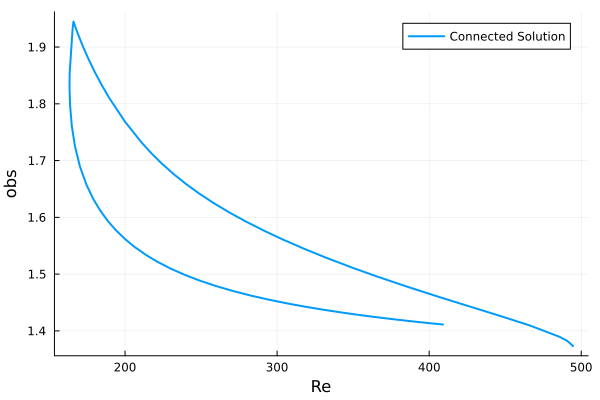

In [39]:
using CSV, DataFrames, Plots

df_top = CSV.read("topbranch.asc", DataFrame; delim=' ', ignorerepeated=true)
df_bot = CSV.read("bottombranch.asc", DataFrame; delim=' ', ignorerepeated=true)
sort!(df_top, 1, rev=true) # Sort by Re descending
df_combined = vcat(df_top, df_bot)
plot(df_combined[!, 1], df_combined[!, 2], 
     label="Connected Solution", xlabel="Re", ylabel="obs", lw=2)

# CSV.write(df_combined, "tw1_combined.asc")